In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [3]:
print("Environment Ready")

Environment Ready


In [4]:
import requests
import pandas as pd

# Nashik Coordinates
LAT = 19.9975
LON = 73.7898

url = (
    "https://power.larc.nasa.gov/api/temporal/monthly/point"
    f"?parameters=T2M,PRECTOTCORR,RH2M"
    f"&community=AG"
    f"&longitude={LON}"
    f"&latitude={LAT}"
    f"&start=2020"
    f"&end=2024"
    f"&format=JSON"
)

response = requests.get(url)

data = response.json()

print(data.keys())

dict_keys(['type', 'geometry', 'properties', 'header', 'messages', 'parameters', 'times'])


In [5]:
parameters = data["properties"]["parameter"]

temperature = parameters["T2M"]
rainfall = parameters["PRECTOTCORR"]
humidity = parameters["RH2M"]

print("Temperature Sample:")
print(list(temperature.items())[:5])

Temperature Sample:
[('202001', 18.69), ('202002', 23.03), ('202003', 25.01), ('202004', 30.06), ('202005', 30.65)]


In [6]:
df = pd.DataFrame({
    "Temperature": temperature,
    "Rainfall": rainfall,
    "Humidity": humidity
})

df = df.reset_index()
df.rename(columns={"index": "Date"}, inplace=True)

df.head()

,Date,Temperature,Rainfall,Humidity
0,202001,18.69,0.00,62.35
1,202002,23.03,0.00,37.13
2,202003,25.01,0.15,41.73
3,202004,30.06,0.02,34.13
4,202005,30.65,0.31,48.81


In [7]:
df["Date"] = pd.to_datetime(df["Date"].astype(str), format="%Y%m", errors="coerce")

df.head()

,Date,Temperature,Rainfall,Humidity
0,2020-01-01,18.69,0.00,62.35
1,2020-02-01,23.03,0.00,37.13
2,2020-03-01,25.01,0.15,41.73
3,2020-04-01,30.06,0.02,34.13
4,2020-05-01,30.65,0.31,48.81


In [8]:
print(df.dtypes)

Date           datetime64[us]
Temperature           float64
Rainfall              float64
Humidity              float64
dtype: object


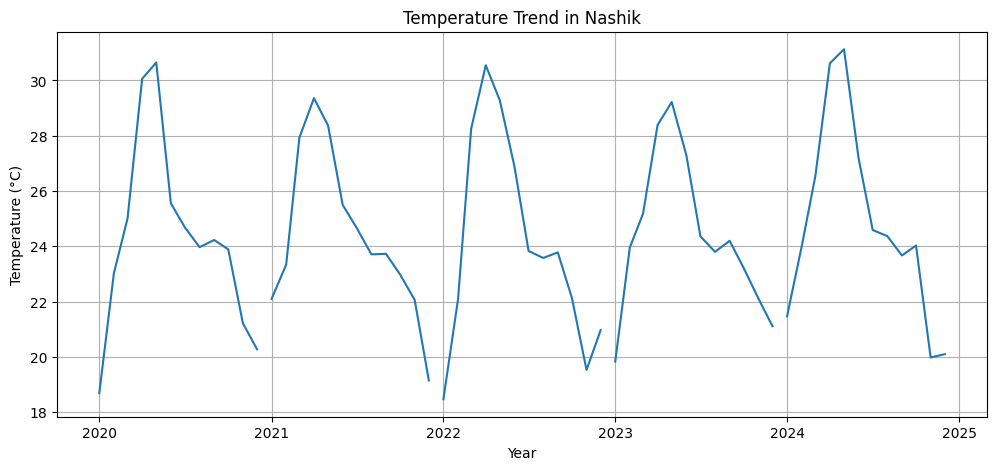

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Temperature"])

plt.title("Temperature Trend in Nashik")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

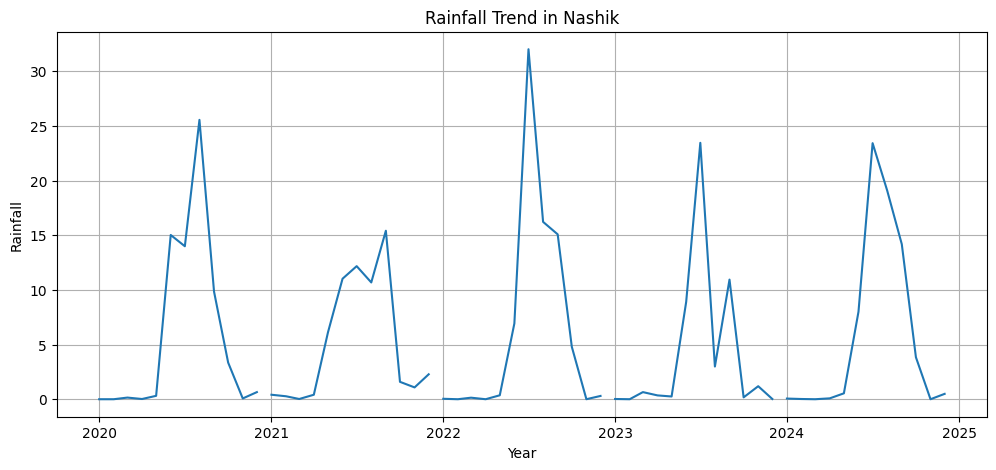

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Rainfall"])

plt.title("Rainfall Trend in Nashik")
plt.xlabel("Year")
plt.ylabel("Rainfall")

plt.grid(True)

plt.show()

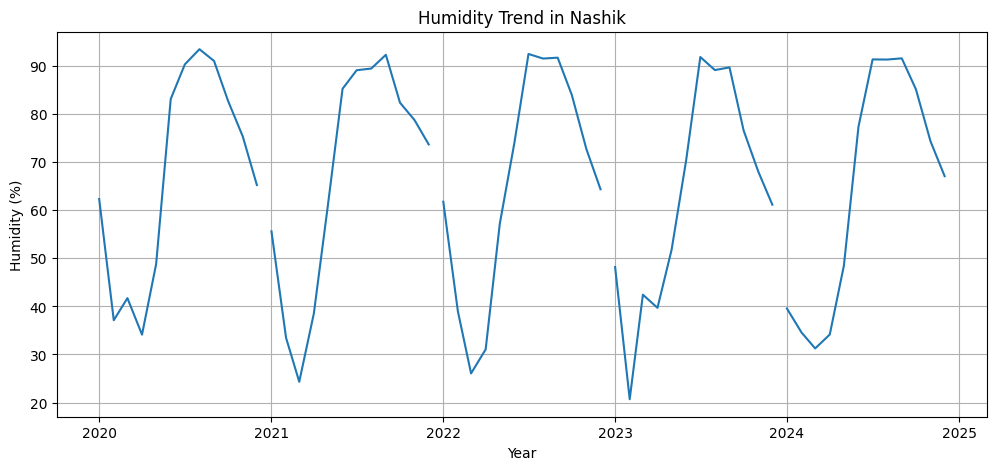

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Humidity"])

plt.title("Humidity Trend in Nashik")
plt.xlabel("Year")
plt.ylabel("Humidity (%)")

plt.grid(True)

plt.show()

In [12]:
df.to_csv("../data/processed/nashik_climate_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [13]:
avg_temp = df["Temperature"].mean()

df["Temp_Anomaly"] = df["Temperature"] - avg_temp

df.head()

,Date,Temperature,Rainfall,Humidity,Temp_Anomaly
0,2020-01-01,18.69,0.00,62.35,-5.707077
1,2020-02-01,23.03,0.00,37.13,-1.367077
2,2020-03-01,25.01,0.15,41.73,0.612923
3,2020-04-01,30.06,0.02,34.13,5.662923
4,2020-05-01,30.65,0.31,48.81,6.252923


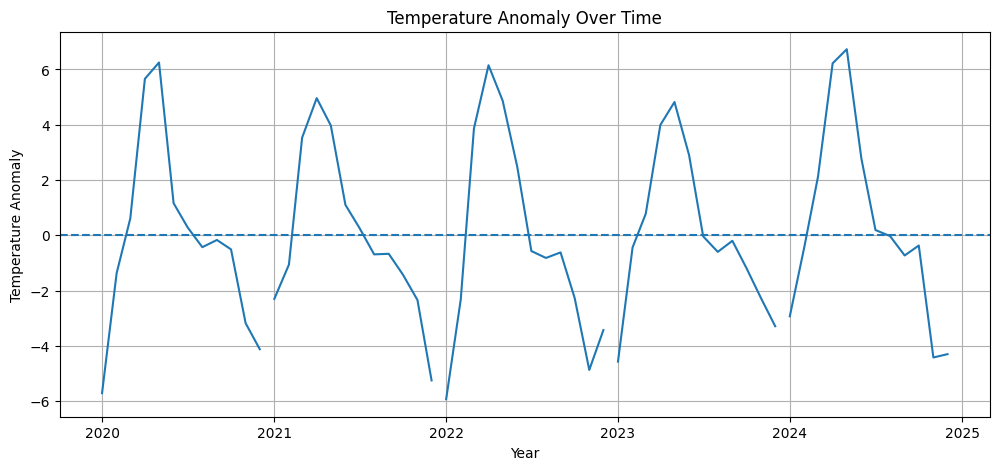

In [14]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Temp_Anomaly"])

plt.axhline(0, linestyle='--')

plt.title("Temperature Anomaly Over Time")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly")

plt.grid(True)

plt.show()

In [15]:
df["Temp_Moving_Avg"] = df["Temperature"].rolling(window=3).mean()

df.head()

,Date,Temperature,Rainfall,Humidity,Temp_Anomaly,Temp_Moving_Avg
0,2020-01-01,18.69,0.00,62.35,-5.707077,NaN
1,2020-02-01,23.03,0.00,37.13,-1.367077,NaN
2,2020-03-01,25.01,0.15,41.73,0.612923,22.243333
3,2020-04-01,30.06,0.02,34.13,5.662923,26.033333
4,2020-05-01,30.65,0.31,48.81,6.252923,28.573333


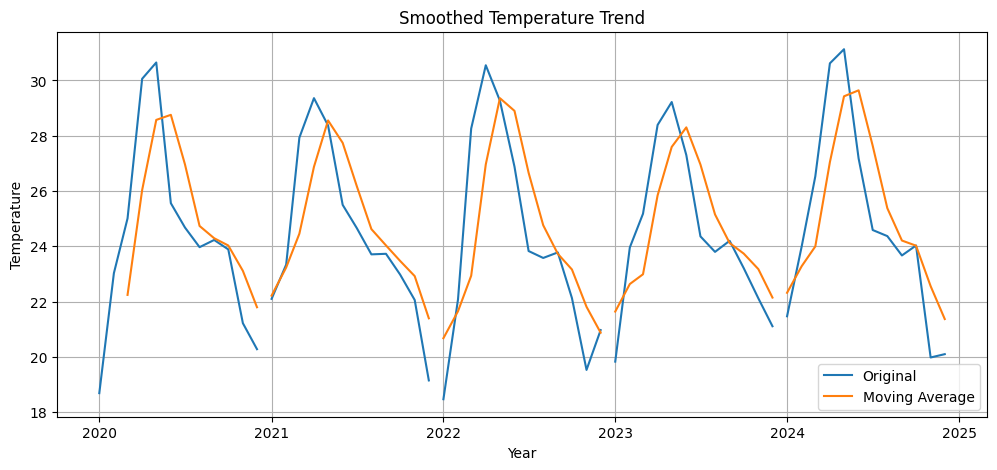

In [16]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Temperature"], label="Original")
plt.plot(df["Date"], df["Temp_Moving_Avg"], label="Moving Average")

plt.title("Smoothed Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Temperature")

plt.legend()

plt.grid(True)

plt.show()

In [17]:
avg_rainfall = df["Rainfall"].mean()

df["Rainfall_Anomaly"] = df["Rainfall"] - avg_rainfall

df.head()

,Date,Temperature,Rainfall,Humidity,Temp_Anomaly,Temp_Moving_Avg,Rainfall_Anomaly
0,2020-01-01,18.69,0.00,62.35,-5.707077,NaN,-5.417846
1,2020-02-01,23.03,0.00,37.13,-1.367077,NaN,-5.417846
2,2020-03-01,25.01,0.15,41.73,0.612923,22.243333,-5.267846
3,2020-04-01,30.06,0.02,34.13,5.662923,26.033333,-5.397846
4,2020-05-01,30.65,0.31,48.81,6.252923,28.573333,-5.107846


In [18]:
df.to_csv("../data/processed/nashik_climate_features.csv", index=False)

print("Enhanced climate dataset saved!")

Enhanced climate dataset saved!
